In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
from numpy.matlib import repmat
from sklearn.preprocessing import normalize
from PIL import Image

In [2]:
print(os.getcwd())

/home/s2lo/final_project


In [3]:
data = []

folder = "/home/s2lo/final_project/GIT_folder/data_R"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    data.append(img)

faces_right = np.array(data)
print("Data matrix shape:", faces_right.shape)

Data matrix shape: (100, 1024, 1024)


In [4]:
def viewcolumn(columnvector):
    # viewcolumn(columnvector)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')


def normc(Mat):
    # normc(M) normalizes the columns of M to a length of 1
    return normalize(Mat, norm='l2', axis=0)

def viewface(n):
    # to view the nth face (to view 10th, write n=9)
    plt.imshow(faces_right[n], cmap='gray')
    plt.axis('off')

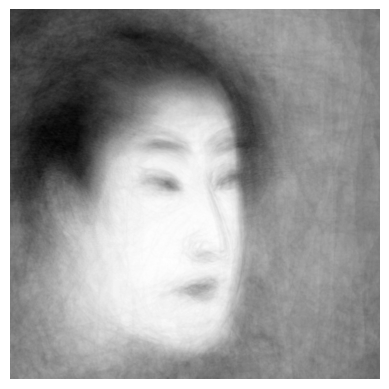

In [5]:
meanface = np.mean(faces_right,axis=0)

viewcolumn(meanface)

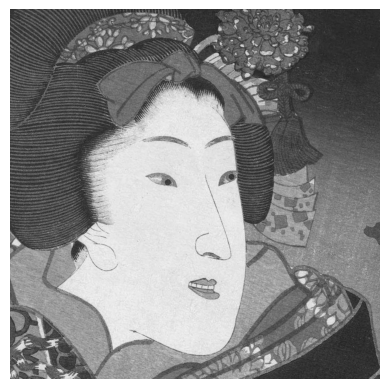

In [6]:
viewface(10)

notes:
1. made data 1D below so we can do 1D math (data reduction) for PCA, but then convert to 2D again (1024x1024) to display images

In [7]:
data_flat = []


folder = "/home/s2lo/final_project/GIT_folder/data_R"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    arr = np.array(img).flatten(order="C")             # flatten to 1D vector
    data_flat.append(arr)

faces_flat_right = np.array(data_flat)
print("Data matrix shape:", faces_flat_right.shape)

Data matrix shape: (100, 1048576)


In [8]:
def viewcolumnflat(columnvector):
    # viewcolumn(columnvector)
    columnvector = columnvector.reshape(1024,1024)
    plt.imshow(columnvector, cmap='gray')
    plt.axis('off')

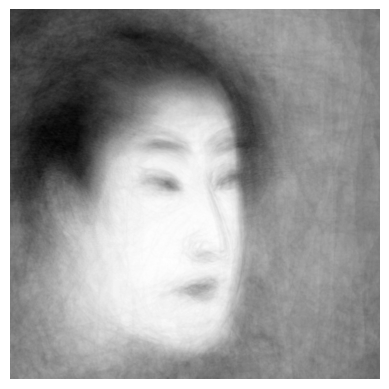

In [9]:
meanface_flat_right = np.mean(faces_flat_right,axis=0, keepdims=True)

viewcolumnflat(meanface_flat_right)

In [10]:
import scipy.sparse as sc

In [11]:
# come back to this: likely messed up the tranposing somewhere ??

print(faces_flat_right.shape)
faces_flat_right = np.array(data_flat).T
print(faces_flat_right.shape)
print(meanface_flat_right.shape)
meanface_flat_right = np.array(meanface_flat_right).T
print(meanface_flat_right.shape)

(100, 1048576)
(1048576, 100)
(1, 1048576)
(1048576, 1)


In [12]:
A = faces_flat_right - np.matlib.repmat(meanface_flat_right, 1, 100)
eigvals, V = np.linalg.eigh(A.T @ A)
index = np.argsort(-eigvals)
eigvals = eigvals[index]
V = V[:, index]

# choose how many eigenfaces to keep
k = 100
V = V[:, :k]
U = A @ V

In [13]:
# note to self: imaginary part is 0 (0.j) in all values, so can disregard (see below)
U

array([[ 2.06334199e+02,  2.16283482e+02, -1.01985637e+02, ...,
        -2.55541397e+01,  4.65404039e+01, -1.18662236e-12],
       [ 2.26758811e+02,  2.06415440e+02, -9.76496731e+01, ...,
        -1.89880238e+01,  5.83492772e+01, -1.31336175e-12],
       [ 2.27401824e+02,  2.01490022e+02, -1.01145262e+02, ...,
        -2.39052875e+00,  6.32200615e+01, -1.34343081e-12],
       ...,
       [ 3.56745371e+02,  4.35091466e+01, -2.11281455e+02, ...,
         1.22943061e+00,  1.82231278e+00, -7.86989141e-13],
       [ 3.48267844e+02,  4.68976859e+01, -1.84663808e+02, ...,
         1.22232959e+01,  4.70044034e+00, -7.20673521e-13],
       [ 3.60327577e+02,  4.57422015e+01, -1.75356378e+02, ...,
         1.95267916e+00,  2.05248303e-01, -8.20419621e-13]])

In [14]:
U = U.astype(float)
U = normc(U)

In [15]:
U.shape

(1048576, 100)

In [16]:
faces_flat_right.shape

(1048576, 100)

In [17]:
face1_right = faces_flat_right[:, 1][:, None]
c = U.T @ (face1_right - meanface_flat_right)

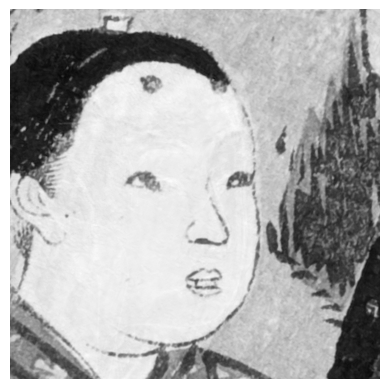

In [18]:
Zhat = U @ c + meanface_flat_right

viewcolumnflat(Zhat)

(-0.5, 1023.5, 1023.5, -0.5)

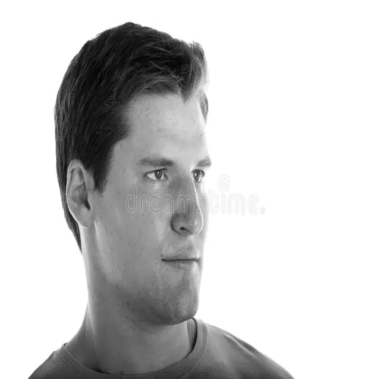

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = '/home/s2lo/final_project/faces/man_right_face.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))

img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
man_face_R = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

In [20]:
c = U.T @ (man_face_R - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

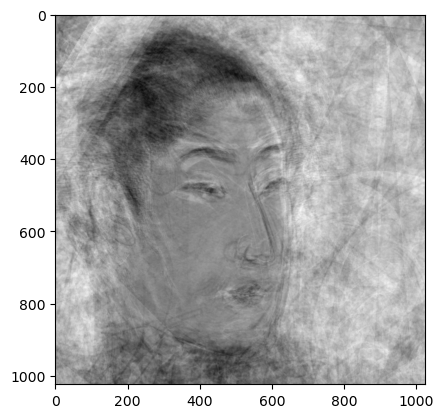

In [21]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

(-0.5, 1023.5, 1023.5, -0.5)

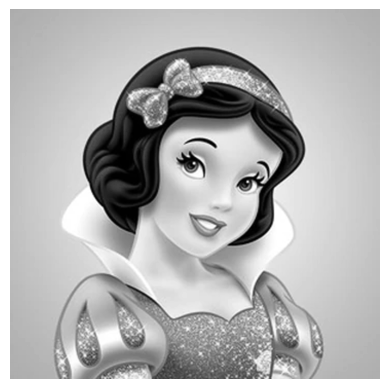

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = '/home/s2lo/final_project/faces/snow_white.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))

img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
snow_white_R = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

In [23]:
c = U.T @ (snow_white_R - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

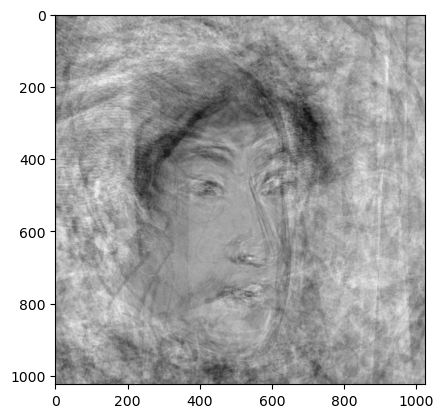

In [24]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

(-0.5, 1023.5, 1023.5, -0.5)

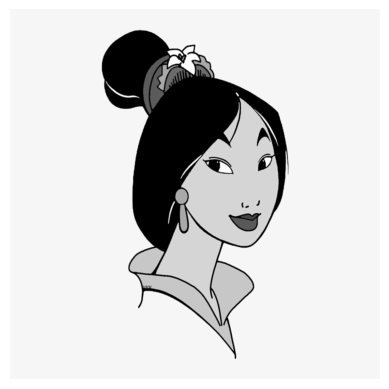

In [25]:
image_path = '/home/s2lo/final_project/faces/mulan_face.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))

img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
mulan_R = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

In [26]:
c = U.T @ (mulan_R - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

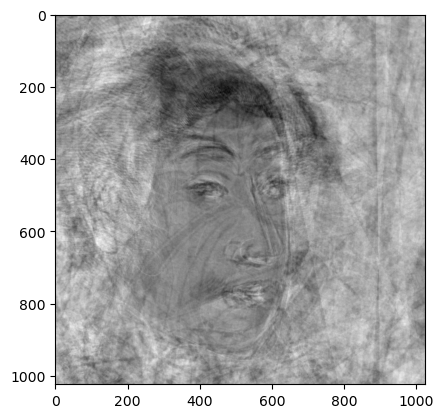

In [27]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

(-0.5, 1023.5, 1023.5, -0.5)

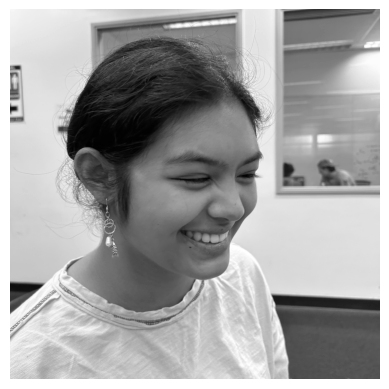

In [28]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = '/home/s2lo/final_project/faces/claire_square.jpg'
img = Image.open(image_path)
img_gray = img.convert("L")   # make image gray
img_resized = img_gray.resize((1024, 1024))

img_arr = np.array(img_resized)
img_flatten = img_arr.flatten()
claire_R = img_flatten.reshape((1048576,1))

plt.imshow(img_arr, cmap='gray')
plt.axis('off')

In [29]:
c = U.T @ (claire_R - meanface_flat_right)
Zhat = U @ c + meanface_flat_right

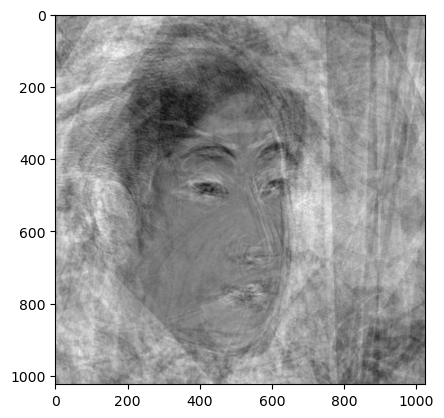

In [30]:
plt.imshow(Zhat.reshape(1024,1024), cmap='gray')

notes:
1. split faces into left, right, and front facing
2. run 3 separate PCA reconstructions using these for face alignment (i.e. reconstruct right facing face w/ right faces PCA)
3. try and compare these faces to faces in CLIP and see where things point (?), and then can try to add in another face (e.g. one of our faces) and see if it can stylistically transfer 